In [40]:
# Importing relevant libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as ticker

# Getting directory where the notebook is located
notebook_dir = Path.cwd()

# Naviating to folder that contains datasets
data_dir = notebook_dir.parent/'dataset'

# Creating DataFrames for each file
aisles = pd.read_csv(data_dir / 'aisles.csv')
departments = pd.read_csv(data_dir / 'departments.csv')
orders = pd.read_csv(data_dir / 'orders.csv')
products = pd.read_csv(data_dir / 'products.csv')
order_products_prior = pd.read_csv(data_dir / 'order_products__prior.csv')

In [41]:
# Reviewing data structure to see what columns/files are relevant

aisles.info()
departments.info()
orders.info()
products.info()
order_products_prior.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 468.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               in

In [42]:
order_history = (pd.merge(order_products_prior, products, how='inner', on='product_id')
                 .merge(departments, how='inner', on='department_id')
                 .merge(aisles, how='inner', on='aisle_id'))
order_history = (order_history
                 .drop(columns=['aisle_id', 'department_id'], axis=1))
order_history.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,department,aisle
0,2,33120,1,1,Organic Egg Whites,dairy eggs,eggs
1,2,28985,2,1,Michigan Organic Kale,produce,fresh vegetables
2,2,9327,3,0,Garlic Powder,pantry,spices seasonings
3,2,45918,4,1,Coconut Butter,pantry,oils vinegars
4,2,30035,5,0,Natural Sweetener,pantry,baking ingredients


In [82]:
days = {0: 'Sunday', 
        1:'Monday', 
        2:'Tuesday', 
        3:'Wednesday', 
        4:'Thursday', 
        5:'Friday', 
        6:'Saturday'}

weekend_map = {
    'Sunday': 'Weekend',
    'Monday': 'Weekday',
    'Tuesday': 'Weekday',
    'Wednesday': 'Weekday',
    'Thursday': 'Weekday',
    'Friday': 'Weekday',
    'Saturday': 'Weekend'}

orders['day_name'] = orders['order_dow'].map(days)
orders['day_type'] = orders['day_name'].map(weekend_map)
orders_final = orders[orders['eval_set'].isin(['prior', 'train'])]
orders_final.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,day_name,day_type
0,2539329,1,prior,1,2,8,NaN,Tuesday,Weekday
1,2398795,1,prior,2,3,7,15.0,Wednesday,Weekday
2,473747,1,prior,3,3,12,21.0,Wednesday,Weekday
3,2254736,1,prior,4,4,7,29.0,Thursday,Weekday
4,431534,1,prior,5,4,15,28.0,Thursday,Weekday


In [44]:
full_history = pd.merge(order_history, orders_final, how='inner', on='order_id')
full_history.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,department,aisle,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,day_name,day_type
0,2,33120,1,1,Organic Egg Whites,dairy eggs,eggs,202279,prior,3,5,9,8.0,Friday,Weekday
1,2,28985,2,1,Michigan Organic Kale,produce,fresh vegetables,202279,prior,3,5,9,8.0,Friday,Weekday
2,2,9327,3,0,Garlic Powder,pantry,spices seasonings,202279,prior,3,5,9,8.0,Friday,Weekday
3,2,45918,4,1,Coconut Butter,pantry,oils vinegars,202279,prior,3,5,9,8.0,Friday,Weekday
4,2,30035,5,0,Natural Sweetener,pantry,baking ingredients,202279,prior,3,5,9,8.0,Friday,Weekday


**Data Cleaning Steps**

- Only one file containued blank values, which was the orders file
    - This is possible though given that the every users' first order will not have days since the prior order
- Merged the files into three primary datasets
    - **order_history**: Breaks down items that were in each order along with the product, department, and aisle
    - **orders_final**: Provides user IDs and order details for each order
        - This dataset was initially for machine learning purposes so am only filtering for the prior and train values and not the test values which would have been used to train the data model
    - **full_history**: Joins together order_history and orders_final

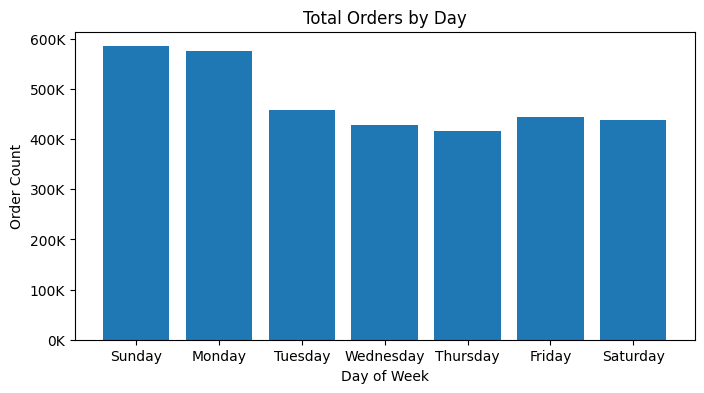

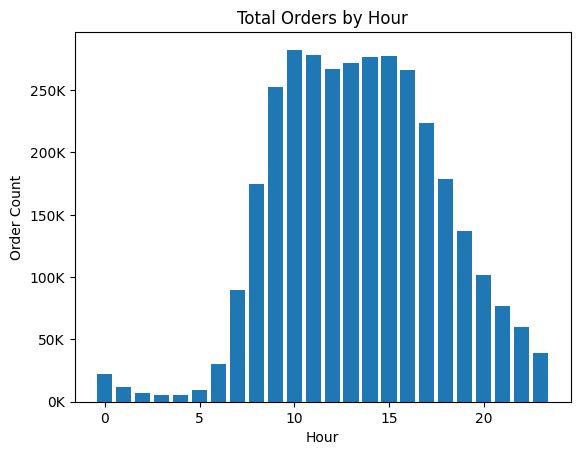

In [72]:
orders_by_day = (orders_final.groupby(['order_dow', 'day_name'])['order_id'] # Grouping order_id by day
                 .count() # Count of order_id
                 .reset_index(name='order_count') # Cleaning up DataFrame
                 .sort_values(by='order_dow', ascending=True)) # Sort on day of week number ascending


# Plotting orders by day
plt.figure(figsize=(8, 4))
plt.bar(orders_by_day.day_name, orders_by_day.order_count)
plt.xlabel('Day of Week')
plt.ylabel('Order Count')
plt.title('Total Orders by Day')
ax = plt.gca()  # Get current axes
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))

plt.show()
orders_by_day

orders_by_hour = (orders_final.groupby(['order_hour_of_day'])['order_id'] # Grouping order_id by hour
                 .count() # Count of order_id
                 .reset_index(name='order_count') # Cleaning up DataFrame
                 .sort_values(by='order_hour_of_day', ascending=True)
                 ) # Sort on day of week number ascending

# Plotting orders by hour

plt.bar(orders_by_hour.order_hour_of_day, orders_by_hour.order_count)
plt.xlabel('Hour')
plt.ylabel('Order Count')
plt.title('Total Orders by Hour')
ax = plt.gca()  # Get current axes
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))

plt.show()

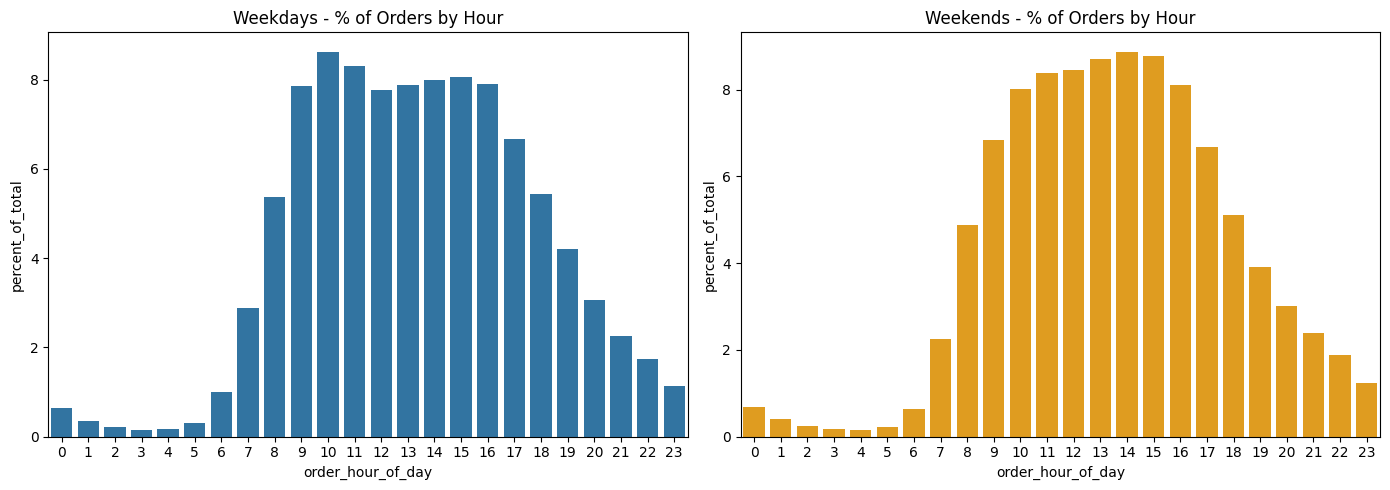

In [79]:

weekdays = (orders_final[orders_final['day_type'] == 'Weekday']
            .groupby(['order_hour_of_day'])['order_id']
            .count()
            .reset_index(name='order_count'))
weekdays['percent_of_total'] = round((weekdays['order_count'] / (weekdays['order_count'].sum()))*100, 2)
weekdays['avg_order_per_day'] = round(weekdays['order_count'] / 5)

weekends = (orders_final[orders_final['day_type'] == 'Weekend']
            .groupby(['order_hour_of_day'])['order_id']
            .count()
            .reset_index(name='order_count'))
weekends['percent_of_total'] = round((weekends['order_count'] / (weekends['order_count'].sum()))*100, 2)
weekends['avg_order_per_day'] = round(weekends['order_count'] / 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='order_hour_of_day', y='percent_of_total', data=weekdays, ax=axes[0])
axes[0].set_title('Weekdays - % of Orders by Hour')

sns.barplot(x='order_hour_of_day', y='percent_of_total', data=weekends, ax=axes[1], color='orange')
axes[1].set_title('Weekends - % of Orders by Hour')

plt.tight_layout()  # Prevents labels from overlapping
plt.show()


**Weekends vs. Weekdays**
- Sundays and Mondays are the highest order volume days with Sunday seeing slightly more orders
- Orders taper off as the week progresses but sees slight pick up on Friday and Saturday before reaching the peak days
- Roughly 65% of orders are placed during the 9AM to 5PM window

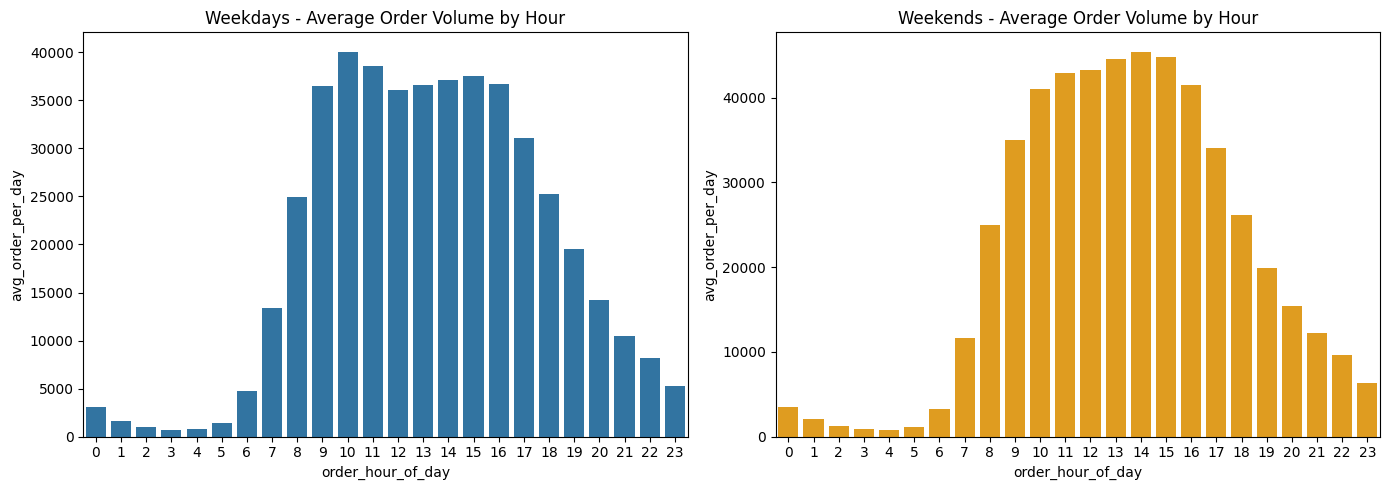

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='order_hour_of_day', y='avg_order_per_day', data=weekdays, ax=axes[0])
axes[0].set_title('Weekdays - Average Order Volume by Hour')

sns.barplot(x='order_hour_of_day', y='avg_order_per_day', data=weekends, ax=axes[1], color='orange')
axes[1].set_title('Weekends - Average Order Volume by Hour')

plt.tight_layout()  # Prevents labels from overlapping
plt.show()
